<a href="https://colab.research.google.com/github/imelda18/ai/blob/main/Albanian_NLP_v2_(2)final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Albanian NLP Pipeline — NER & Text Classification
**Kategorizimi i Teksteve dhe Identifikimi i Entiteteve (NER) në Gjuhën Shqipe**

Ky notebook implementon:
- Përgatitja e korpusit + metadata DB
- Pastrimi dhe lidhja e niveleve (NER + POS + LEMMA) — **pa normalizim etiketash**
- Ndarje e korpusit **sipas artikujve** (jo fjalive), me diversifikim etiketash
- Text Classification: TF-IDF, CountVec, POS features, Lemma features, BiLSTM-Attn, XLM-RoBERTa
- NER: BiLSTM, BiLSTM-CRF, Attention-BiLSTM, mBERT, XLM-RoBERTa
- **Tabelë përmbledhëse** P/R/F1 për çdo model
- GUI Gradio me etiketat reale NER


In [10]:
# CELL 1 — MOUNT GOOGLE DRIVE
from google.colab import drive
import os
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
print('Drive i montuar')

Drive i montuar


In [2]:
# CELL 2 — INSTALIMI
!pip install -q \
    transformers==4.44.2 \
    datasets==2.21.0 \
    accelerate==0.34.2 \
    seqeval==1.2.2 \
    pytorch-crf==0.7.2 \
    gradio==4.44.0 \
    stanza \
    evaluate \
    scikit-learn \
    seaborn
print('Instalimet u kryen')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 107.0 MB/s eta 0:00:00
   ━

In [3]:
# CELL 3 — IMPORTET
import os, re, glob, json, pickle, warnings, random, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, precision_recall_fscore_support)

import torch, torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader

from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                          AutoModelForSequenceClassification,
                          TrainingArguments, Trainer,
                          DataCollatorForTokenClassification)
from datasets import Dataset as HFDataset

try:
    from torchcrf import CRF
    HAS_CRF = True
    print('torchcrf i disponueshëm')
except ImportError:
    HAS_CRF = False
    print('torchcrf nuk u gjet — do përdoret fallback')

from seqeval.metrics import (f1_score as seq_f1,
                              classification_report as seq_report,
                              precision_score as seq_prec,
                              recall_score as seq_rec)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print('Importet u kryen')

torchcrf i disponueshëm
Device: cuda
Importet u kryen


In [12]:
# CELL 4 — KONFIGURIMI
DATA_DIR  = '/content/drive/MyDrive/Combined Files in Corpus/'
SAVE_DIR  = '/content/drive/MyDrive/models/'
os.makedirs(SAVE_DIR, exist_ok=True)

EMBED_DIM  = 100
HIDDEN_DIM = 256
DROPOUT    = 0.3
MAX_LEN    = 128
BATCH_SIZE = 32
EPOCHS_LSTM = 20
EPOCHS_BERT = 5
LR_LSTM    = 1e-3
LR_BERT    = 2e-5

CATEGORY_KEYWORDS = {
    'sociale': ['sociale', 'social'],
    'culture': ['culture', 'kulture'],
    'tech':    ['tech'],
}

def make_training_args(out_dir, **kwargs):
    return TrainingArguments(output_dir=out_dir, **kwargs)

print('Konfigurimi u krye')

Konfigurimi u krye


## PJESA 1 — Përgatitja e Korpusit

In [13]:
# CELL 5 — PARSERS + METADATA HELPERS

def parse_conllu(filepath):
    """Parse CoNLL-U — nxjerr tokens, POS, LEMMA, NER dhe metadata."""
    sentences, current, meta = [], [], {}
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if line.startswith('# text ='):       meta['text']    = line[9:].strip()
            elif line.startswith('# sent_id ='):  meta['sent_id'] = line[12:].strip()
            elif line.startswith('#'):             continue
            elif line == '':
                if current:
                    sentences.append({'meta': dict(meta), 'tokens': current})
                    current, meta = [], {}
            else:
                parts = line.split('\t')
                if len(parts) < 10 or '-' in parts[0] or '.' in parts[0]: continue
                ner = next((m[4:] for m in parts[9].split('|') if m.startswith('NER=')), 'O')
                current.append({
                    'form':   parts[1],
                    'lemma':  parts[2],
                    'upos':   parts[3],
                    'feats':  parts[5],
                    'head':   parts[6],
                    'deprel': parts[7],
                    'ner':    ner
                })
    if current:
        sentences.append({'meta': dict(meta), 'tokens': current})
    return sentences


def parse_ner_txt(filepath):
    """Parse NER .txt — çdo rresht: WORD TAB TAG."""
    sentences, current = [], []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == '':
                if current:
                    sentences.append({'meta': {}, 'tokens': current})
                    current = []
            else:
                p = line.split('\t')
                tag = p[-1].strip() if len(p) >= 2 else 'O'
                current.append({'form': p[0], 'lemma': p[0],
                                 'upos': 'X', 'feats': '_', 'ner': tag})
    if current:
        sentences.append({'meta': {}, 'tokens': current})
    return sentences


def infer_category(fname):
    fn = fname.lower()
    for cat, kws in CATEGORY_KEYWORDS.items():
        if any(k in fn for k in kws): return cat
    return 'general'

def infer_source(fname):
    fn = fname.lower()
    return 'rtsh' if 'rtsh' in fn else ('ata' if 'ata' in fn else 'unknown')

def extract_date_from_fname(fname):
    m = re.search(r'(\d{4})', fname)
    return m.group(1) if m else 'unknown'

print('Parsers janë gati')

Parsers janë gati


In [14]:
# CELL 6 — NGARKIMI I TË DHËNAVE + METADATA DB
# ✅ Përdorim VETËM skedarët .conllu (Combined Files in Corpus)
# Arsye: .conllu përmban gjithçka — form, lemma, POS, feats, deprel, NER
# Skedarët .txt (NER Files) janë eksport i thjeshtëzuar i të njëjtave të dhëna
# dhe do të shkaktonin duplifikim nëse ngarkohen njëkohësisht.

all_articles = []   # çdo element = një artikull (skedar)
all_docs     = []   # metadata

all_files = sorted(glob.glob(os.path.join(DATA_DIR, '**/*.conllu'), recursive=True))
print(f'Skedarë .conllu të gjetur: {len(all_files)}')

for fp in all_files:
    fname    = os.path.basename(fp)
    category = infer_category(fname)
    source   = infer_source(fname)
    date_pub = extract_date_from_fname(fname)

    sents = parse_conllu(fp)
    if not sents: continue

    title = sents[0]['meta'].get('text',
            ' '.join(t['form'] for t in sents[0]['tokens'][:10]))
    text_raw   = ' '.join(t['form']  for s in sents for t in s['tokens'])
    text_lemma = ' '.join(t['lemma'] for s in sents for t in s['tokens'])

    for s in sents:
        s.update({'category': category, 'source': source,
                  'file': fname, 'title': title, 'date': date_pub})

    ner_lbls = list(set(t['ner'] for s in sents for t in s['tokens'] if t['ner'] != 'O'))

    all_articles.append({
        'filename':   fname,
        'category':   category,
        'source':     source,
        'date':       date_pub,
        'title':      title,
        'sents':      sents,
        'text_raw':   text_raw,
        'text_lemma': text_lemma,
        'ner_labels': ner_lbls,
    })
    all_docs.append({
        'filename':   fname,
        'title':      title,
        'url':        f'https://{source}.al/{category}/{fname}',
        'category':   category,
        'source':     source,
        'date':       date_pub,
        'text':       text_raw,
        'text_lemma': text_lemma,
        'n_sents':    len(sents),
        'n_tokens':   len(text_raw.split()),
        'ner_labels': ner_lbls,
    })

docs_df = pd.DataFrame(all_docs)
docs_df.to_csv(SAVE_DIR + 'metadata_db.csv', index=False)

print(f'\nArtikuj total:   {len(all_articles):,}')
print(f'Kategoritë:')
print(docs_df['category'].value_counts())
print(f'\nMetadata DB u ruajt: {SAVE_DIR}metadata_db.csv')


Skedarë .conllu të gjetur: 4681

Artikuj total:   4,680
Kategoritë:
category
sociale    2350
culture    1410
general     896
tech         24
Name: count, dtype: int64

Metadata DB u ruajt: /content/drive/MyDrive/models/metadata_db.csv


In [15]:
# CELL 6b — RUAJTJA E ÇDO ARTIKULLI SI FILE TEKST + METADATA JSON
# ✅ Detyrë: "Çdo artikull të ruhet në një file tekst"

ARTICLES_DIR = SAVE_DIR + 'articles/'
os.makedirs(ARTICLES_DIR, exist_ok=True)

for art in all_articles:
    # ── 1. File tekst me përmbajtjen e artikullit ─────────────────────────────
    safe_name = re.sub(r'[^\w\-.]', '_', art['filename'].replace('.conllu', ''))
    txt_path  = os.path.join(ARTICLES_DIR, safe_name + '.txt')
    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write(art['text_raw'])

    # ── 2. File JSON me metadata të plotë ─────────────────────────────────────
    meta_path = os.path.join(ARTICLES_DIR, safe_name + '_meta.json')
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump({
            'filename':   art['filename'],
            'title':      art['title'],
            'url':        f"https://{art['source']}.al/{art['category']}/{art['filename']}",
            'category':   art['category'],
            'source':     art['source'],
            'date':       art['date'],
            'n_sents':    len(art['sents']),
            'n_tokens':   len(art['text_raw'].split()),
            'ner_labels': art['ner_labels'],
        }, f, ensure_ascii=False, indent=2)

# Statistika
saved_txt  = len(glob.glob(ARTICLES_DIR + '*.txt'))
saved_meta = len(glob.glob(ARTICLES_DIR + '*_meta.json'))
print(f'✅ Artikuj të ruajtur si .txt:       {saved_txt:,}')
print(f'✅ Metadata JSON të ruajtura:         {saved_meta:,}')
print(f'   Shembull: {ARTICLES_DIR}{safe_name}.txt')
print(f'   Shembull: {ARTICLES_DIR}{safe_name}_meta.json')


✅ Artikuj të ruajtur si .txt:       4,509
✅ Metadata JSON të ruajtura:         4,509
   Shembull: /content/drive/MyDrive/models/articles/9_data_lajme_rtsh_al_sociale_headline_combined.txt
   Shembull: /content/drive/MyDrive/models/articles/9_data_lajme_rtsh_al_sociale_headline_combined_meta.json


## PJESA 2 — EDA (Exploratory Data Analysis)

=== STATISTIKA BAZË ===
Artikuj:   4,680
Fjali:     39,226
Tokens:    1,023,483

NER etiketat unikë (të panormalizuara):
ner
O           930389
B-PER        21100
I-DATE_0     13914
I-PER        12855
B-VEND_0     11948
B-VEND_1      9074
B-DATE_0      6631
I-ORG         6514
B-ORG         5215
I-VEND_1      1625
I-EVENT       1089
B-EVENT        685
I-DATE_1       469
B-DATE_1       461
I-VEND_0       339
I-RRUGE        326
B-PRO          310
I-SHESH        173
B-RRUGE        144
B-SHESH        114
Name: count, dtype: int64

POS tags:
upos
NOUN     199289
PUNCT    132079
DET      114868
PROPN     98381
VERB      92973
ADP       90452
ADJ       64156
PRON      60687
PART      52356
NUM       30405
CCONJ     29350
ADV       21360
SCONJ     18386
AUX       15230
_          2198
SYM         967
X           344
INTJ          2
Name: count, dtype: int64


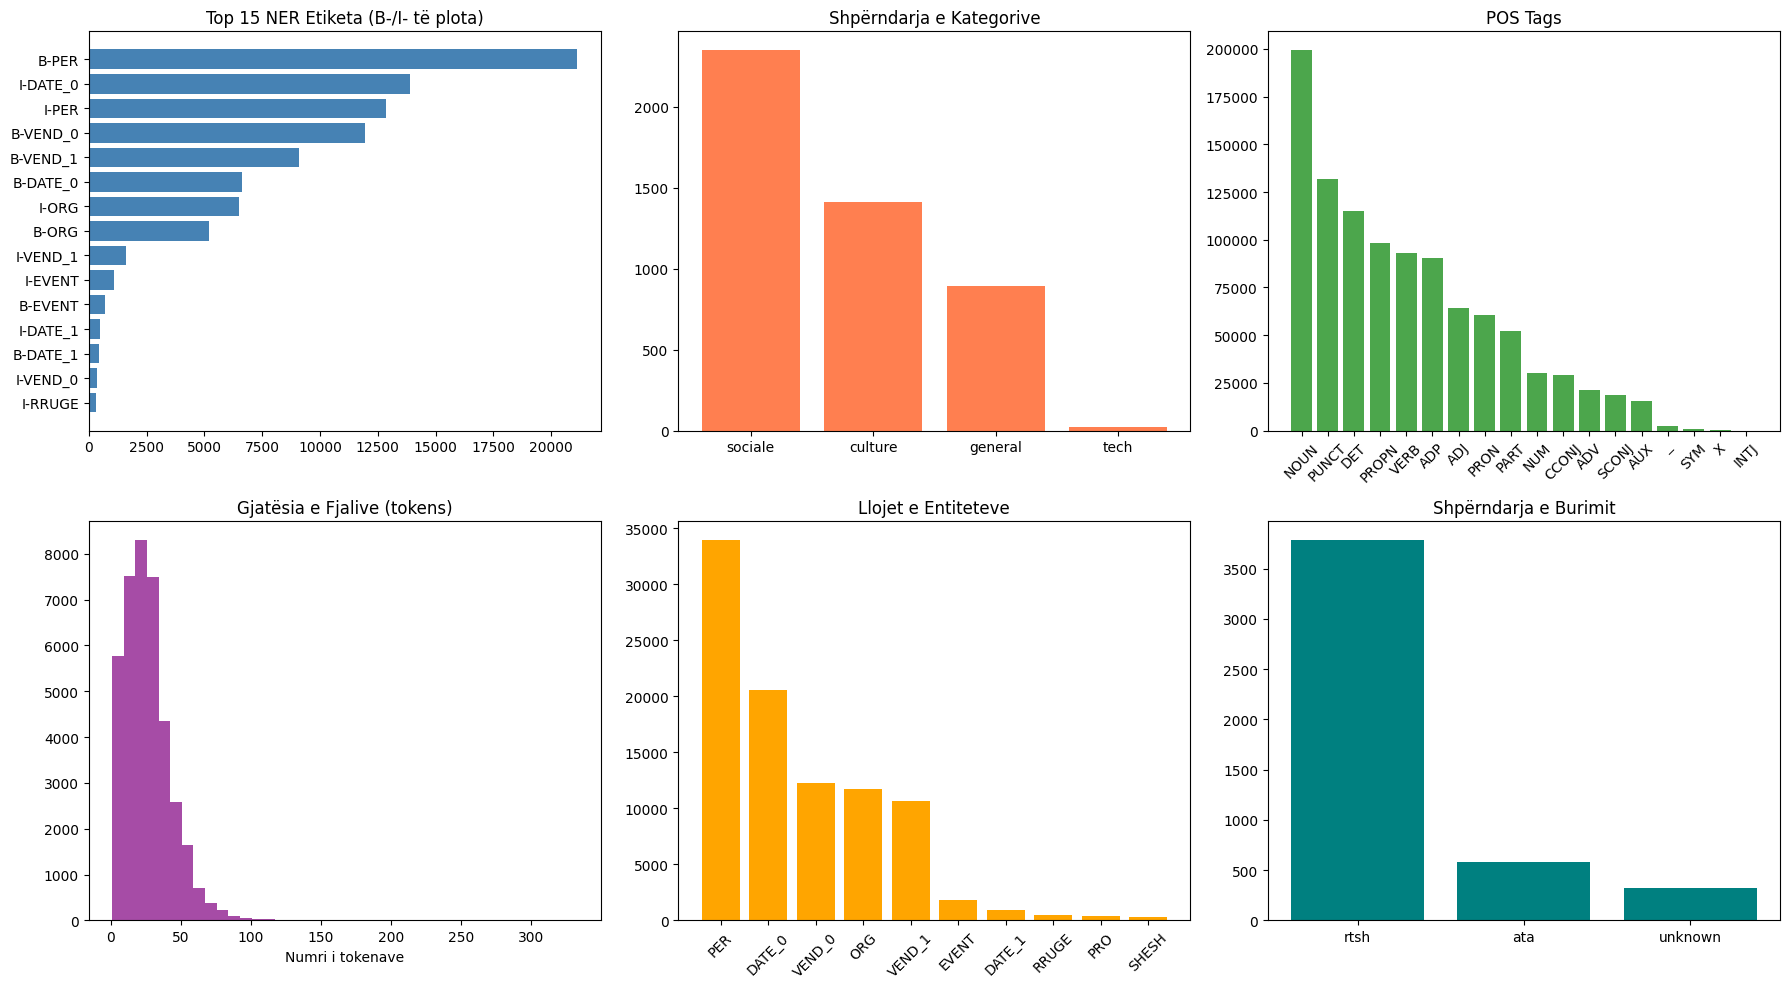

EDA u krye


In [16]:
# CELL 7 — EDA
# Ndërtojmë all_sentences nga artikujt (për backward compat)
all_sentences = [s for art in all_articles for s in art['sents']]

rows = [{'form': t['form'], 'lemma': t['lemma'], 'upos': t.get('upos','X'),
         'ner': t['ner'], 'category': s.get('category','?')}
        for s in all_sentences for t in s['tokens']]
df_tok = pd.DataFrame(rows)

print('=== STATISTIKA BAZË ===')
print(f'Artikuj:   {len(all_articles):,}')
print(f'Fjali:     {len(all_sentences):,}')
print(f'Tokens:    {len(df_tok):,}')
print(f'\nNER etiketat unikë (të panormalizuara):')
print(df_tok['ner'].value_counts().head(20))
print(f'\nPOS tags:')
print(df_tok['upos'].value_counts())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# NER distribution (top 15)
ner_counts = df_tok[df_tok['ner']!='O']['ner'].value_counts().head(15)
axes[0,0].barh(ner_counts.index, ner_counts.values, color='steelblue')
axes[0,0].set_title('Top 15 NER Etiketa (B-/I- të plota)')
axes[0,0].invert_yaxis()

# Category distribution
cat_counts = docs_df['category'].value_counts()
axes[0,1].bar(cat_counts.index, cat_counts.values, color='coral')
axes[0,1].set_title('Shpërndarja e Kategorive')

# POS distribution
pos_counts = df_tok['upos'].value_counts()
axes[0,2].bar(pos_counts.index, pos_counts.values, color='green', alpha=0.7)
axes[0,2].set_title('POS Tags')
axes[0,2].tick_params(axis='x', rotation=45)

# Tokens per sentence
sent_lens = [len(s['tokens']) for s in all_sentences]
axes[1,0].hist(sent_lens, bins=40, color='purple', alpha=0.7)
axes[1,0].set_title('Gjatësia e Fjalive (tokens)')
axes[1,0].set_xlabel('Numri i tokenave')

# NER entity types (without B-/I-)
entity_types = df_tok[df_tok['ner']!='O']['ner'].str.replace(r'^[BI]-','',regex=True)
etype_counts = entity_types.value_counts().head(12)
axes[1,1].bar(etype_counts.index, etype_counts.values, color='orange')
axes[1,1].set_title('Llojet e Entiteteve')
axes[1,1].tick_params(axis='x', rotation=45)

# Source distribution
src_counts = docs_df['source'].value_counts()
axes[1,2].bar(src_counts.index, src_counts.values, color='teal')
axes[1,2].set_title('Shpërndarja e Burimit')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA u krye')

## PJESA 3 — Pastrimi dhe Pre-procesimi

**Ndryshimet kyçe:**
- ⚠ **NER etiketat NDRUK normalizohen** — `DATE_0`, `DATE_1`, `VEND_0`, `VEND_1` janë etiketa të ndryshme me kuptim të ndryshëm (shih tabelën e mëposhtme)
- ✅ Për temëzim përdoret **lemma nga korpusi** (jo rule-based stemmer)
- ✅ Stanza lemmatizer mund të krahasohet opsionalisht

| Etiketë | Kategori | Shpjegim |
|---------|----------|----------|
| PER | Person | emër dhe mbiemër, vetëm emër, vetëm iniciale |
| ORG | Organizatë | parti politike, struktura qeveritare, federata, etj. |
| PRO | Produkt | vaksina, objekte, etj. |
| EVENT | Ngjarje | konferenca, samite, kampionate, etj. |
| VEND_0 | Qytet | emra qytetesh |
| VEND_1 | Shtet | emra shtetesh |
| SHESH | Shesh | emra sheshesh |
| RRUGE | Rrugë | emra rrugësh |
| DATE_0 | Datë | data të plota, vetëm viti, muaji+viti, dita+muaji |
| DATE_1 | Ditë jave | ditët e javës |


In [17]:
# CELL 8 — PASTRIMI DHE LIDHJA E NIVELEVE

# ── NER etiketat RUHEN ASHTU SI JANË (asnjë normalizim) ──────────────────────
# DATE_0 ≠ DATE_1  |  VEND_0 (qytet) ≠ VEND_1 (shtet)

# Ndërtojmë label set nga të dhënat
all_ner_labels = sorted(set(t['ner'] for s in all_sentences for t in s['tokens']))
label2id = {l: i for i, l in enumerate(all_ner_labels)}
id2label  = {i: l for l, i in label2id.items()}
NUM_NER_LABELS = len(all_ner_labels)

# Label encoder për text classification
le = LabelEncoder()
docs_df['label'] = le.fit_transform(docs_df['category'])
class_names  = le.classes_
NUM_CLASSES  = len(class_names)

# ── Shembull lidhje NER + POS + LEMMA (pa normalizim) ────────────────────────
print('=== SHEMBULL LIDHJE NIVELESH (NER + POS + LEMMA) ===')
s0 = next(s for s in all_sentences if any(t['ner'] != 'O' for t in s['tokens']))
print(f'{"FORM":<15} {"LEMMA":<15} {"POS":<8} {"NER":<14}')
print('-' * 54)
for t in s0['tokens'][:15]:
    print(f"{t['form']:<15} {t['lemma']:<15} {t.get('upos','X'):<8} {t['ner']:<14}")

print(f'\nNER etiketa totale: {NUM_NER_LABELS}')
print(f'Etiketat: {all_ner_labels}')
print(f'\nCLF klasa: {NUM_CLASSES} → {list(class_names)}')

=== SHEMBULL LIDHJE NIVELESH (NER + POS + LEMMA) ===
FORM            LEMMA           POS      NER           
------------------------------------------------------
Uji             Uji             NOUN     O             
i               i               DET      O             
Ftohë           Ftohë           PROPN    O             
"               "               PUNCT    O             
në              në              ADP      O             
Tepelenë        Tepelenë        PROPN    B-VEND_0      
,               ,               PUNCT    O             
ndalesa         ndalesë         NOUN     O             
e               e               DET      O             
preferuar       preferuar       ADJ      O             
e               e               DET      O             
turistëve       turist          NOUN     O             
13              13              NUM      B-DATE_0      
/               /               PUNCT    I-DATE_0      
08              08              NUM      I-DATE_0   

## PJESA 4 — Ndarja e Korpusit

**Rëndësia e ndarjes sipas artikujve:**
Të gjitha fjalitë e një artikulli duhet të qëndrojnë në të njëjtën ndarje
(train/dev/test), sepse fjalitë brenda një artikulli janë të lidhura kontekstualisht.
Ndarja e rastësishme e fjalive do të shkaktonte *data leakage*.

**Procedura:**
1. Përziej artikujt rastësisht
2. Ndaj 70% train / 15% dev / 15% test
3. Verifiko diversifikimin e etiketave NER dhe kategorive


In [18]:
# CELL 9 — NDARJE SIPAS ARTIKUJVE (jo fjalive)

random.seed(42)
articles_shuffled = all_articles.copy()
random.shuffle(articles_shuffled)

n = len(articles_shuffled)
n_train = int(0.70 * n)
n_dev   = int(0.85 * n)

train_arts = articles_shuffled[:n_train]
dev_arts   = articles_shuffled[n_train:n_dev]
test_arts  = articles_shuffled[n_dev:]

# Ekstrakto fjalitë nga secila ndarje
train_sents = [s for art in train_arts for s in art['sents']]
dev_sents   = [s for art in dev_arts   for s in art['sents']]
test_sents  = [s for art in test_arts  for s in art['sents']]

print(f'=== NDARJE NER (sipas artikujve) ===')
print(f'  Train: {len(train_arts):>5} artikuj  →  {len(train_sents):>7,} fjali')
print(f'  Dev:   {len(dev_arts):>5} artikuj  →  {len(dev_sents):>7,} fjali')
print(f'  Test:  {len(test_arts):>5} artikuj  →  {len(test_sents):>7,} fjali')

# ── Verifiko diversifikimin e etiketave NER ────────────────────────────────────
def ner_type_dist(sents):
    c = Counter()
    for s in sents:
        for t in s['tokens']:
            if t['ner'] != 'O' and t['ner'].startswith('B-'):
                c[t['ner'][2:]] += 1
    return c

tr_d = ner_type_dist(train_sents)
dv_d = ner_type_dist(dev_sents)
te_d = ner_type_dist(test_sents)
all_types = sorted(set(tr_d) | set(dv_d) | set(te_d))
print(f'\n=== DIVERSIFIKIMI I ETIKETAVE NER ===')
print(f'{"Etiketa":<12} {"Train":>8} {"Dev":>8} {"Test":>8}')
print('-' * 40)
for et in all_types:
    print(f'{et:<12} {tr_d.get(et,0):>8,} {dv_d.get(et,0):>8,} {te_d.get(et,0):>8,}')

# ── Ndarja CLF sipas artikujve ──────────────────────────────────────────────
train_docs = [(art['text_raw'], art['text_lemma'],
               le.transform([art['category']])[0]) for art in train_arts]
dev_docs   = [(art['text_raw'], art['text_lemma'],
               le.transform([art['category']])[0]) for art in dev_arts]
test_docs  = [(art['text_raw'], art['text_lemma'],
               le.transform([art['category']])[0]) for art in test_arts]

X_tr,  X_tr_l,  y_tr  = zip(*train_docs)
X_dev, X_dev_l, y_dev = zip(*dev_docs)
X_te,  X_te_l,  y_te  = zip(*test_docs)
X_tr, X_tr_l, y_tr   = list(X_tr),  list(X_tr_l),  list(y_tr)
X_dev,X_dev_l, y_dev  = list(X_dev), list(X_dev_l), list(y_dev)
X_te,  X_te_l, y_te   = list(X_te),  list(X_te_l),  list(y_te)

print(f'\n=== NDARJE CLF (sipas artikujve) ===')
print(f'  Train: {len(X_tr):,}  Dev: {len(X_dev):,}  Test: {len(X_te):,}')
print(f'  Kategori Train: {Counter(y_tr)}')
print(f'  Kategori Test:  {Counter(y_te)}')

=== NDARJE NER (sipas artikujve) ===
  Train:  3276 artikuj  →   27,304 fjali
  Dev:     702 artikuj  →    6,017 fjali
  Test:    702 artikuj  →    5,905 fjali

=== DIVERSIFIKIMI I ETIKETAVE NER ===
Etiketa         Train      Dev     Test
----------------------------------------
DATE_0          4,667      948    1,016
DATE_1            329       59       73
EVENT             501      101       83
ORG             3,499      795      921
PER            14,822    3,214    3,064
PRO               209       45       56
RRUGE             105       19       20
SHESH              78       14       22
VEND_0          8,456    1,690    1,802
VEND_1          6,414    1,361    1,299

=== NDARJE CLF (sipas artikujve) ===
  Train: 3,276  Dev: 702  Test: 702
  Kategori Train: Counter({np.int64(2): 1674, np.int64(0): 988, np.int64(1): 596, np.int64(3): 18})
  Kategori Test:  Counter({np.int64(2): 336, np.int64(0): 201, np.int64(1): 161, np.int64(3): 4})


## PJESA 5 — Feature Engineering

In [19]:
# CELL 10 — VOCAB, EMBEDDINGS, FEATURES

# ── Vocabulary ────────────────────────────────────────────────────────────────
wc = Counter(t['form'].lower() for s in train_sents for t in s['tokens'])
vocab   = ['<PAD>', '<UNK>'] + list(wc.keys())
word2id = {w: i for i, w in enumerate(vocab)}

# Lemma vocabulary (nga train)
lc = Counter(t['lemma'].lower() for s in train_sents for t in s['tokens'])
lemma_vocab  = ['<PAD>', '<UNK>'] + list(lc.keys())
lemma2id     = {w: i for i, w in enumerate(lemma_vocab)}

pos_vocab = ['<PAD>'] + sorted(set(t.get('upos','X') for s in all_sentences for t in s['tokens']))
pos2id    = {p: i for i, p in enumerate(pos_vocab)}

print(f'Vocabulary (form):  {len(vocab):,}')
print(f'Vocabulary (lemma): {len(lemma_vocab):,}')
print(f'POS vocab:          {pos_vocab}')

# ── FastText Albanian (opsionale) ─────────────────────────────────────────────
FASTTEXT_PATH = '/content/drive/MyDrive/NER_Albanian/cc.sq.300.bin'
USE_FASTTEXT  = False

if os.path.exists(FASTTEXT_PATH):
    try:
        import fasttext
        ft = fasttext.load_model(FASTTEXT_PATH)
        EMBED_DIM = 300; USE_FASTTEXT = True
        embedding_matrix = np.zeros((len(vocab), 300), dtype=np.float32)
        for w, i in word2id.items():
            if w not in ('<PAD>','<UNK>'): embedding_matrix[i] = ft.get_word_vector(w)
        print(f'FastText embeddings: {embedding_matrix.shape}')
    except Exception as e:
        print(f'FastText error: {e}')
else:
    print('FastText nuk u gjet — duke përdorur random embeddings')
    print('(Shkarko cc.sq.300.bin nga fasttext.cc dhe vendose në Drive)')

if not USE_FASTTEXT:
    embedding_matrix = np.random.randn(len(vocab), EMBED_DIM).astype(np.float32) * 0.01
    embedding_matrix[0] = 0

# ── POS sequences për CLF ─────────────────────────────────────────────────────
fname2pos = {}
for s in all_sentences:
    fn = s.get('file', '')
    fname2pos.setdefault(fn, []).append(' '.join(t.get('upos','X') for t in s['tokens']))

def get_pos_text(fname): return ' '.join(fname2pos.get(fname, []))
X_tr_pos  = [get_pos_text(art['filename']) for art in train_arts]
X_te_pos  = [get_pos_text(art['filename']) for art in test_arts]
y_tr_pos  = [le.transform([art['category']])[0] for art in train_arts]
y_te_pos  = [le.transform([art['category']])[0] for art in test_arts]

print('Features janë gati')

Vocabulary (form):  43,820
Vocabulary (lemma): 29,206
POS vocab:          ['<PAD>', 'ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X', '_']
FastText nuk u gjet — duke përdorur random embeddings
(Shkarko cc.sq.300.bin nga fasttext.cc dhe vendose në Drive)
Features janë gati


## PJESA 6 — Text Classification

Teknikat e testuara:
1. TF-IDF Unigram + LR/SVM — tekst origjinal
2. TF-IDF Bigram + LR/SVM — tekst origjinal
3. CountVectorizer — tekst origjinal
4. TF-IDF + Lemma (temëzim nga korpusi)
5. POS Tags si features
6. BiLSTM me Attention
7. XLM-RoBERTa


In [20]:
# CELL 11 — TEXT CLASSIFICATION: TEKNIKAT ML KLASIKE

clf_results  = {}   # {model_name: {'precision':..,'recall':..,'f1':..}}

def run_clf(name, pipe, Xtr, ytr, Xte, yte):
    pipe.fit(Xtr, ytr)
    preds = pipe.predict(Xte)
    p, r, f, _ = precision_recall_fscore_support(yte, preds, average='weighted', zero_division=0)
    clf_results[name] = {'precision': p, 'recall': r, 'f1': f}
    print(f'{name:<42}  P={p:.4f}  R={r:.4f}  F1={f:.4f}')
    return pipe

print('=== TEKNIKA 1: Tekst origjinal + TF-IDF Unigram ===')
run_clf('TF-IDF Unigram + LR',
    Pipeline([('t', TfidfVectorizer(ngram_range=(1,1), max_features=10000, sublinear_tf=True)),
              ('c', LogisticRegression(max_iter=1000, C=1.0, random_state=42))]),
    X_tr, y_tr, X_te, y_te)
run_clf('TF-IDF Unigram + SVM',
    Pipeline([('t', TfidfVectorizer(ngram_range=(1,1), max_features=10000, sublinear_tf=True)),
              ('c', LinearSVC(max_iter=2000, C=1.0, random_state=42))]),
    X_tr, y_tr, X_te, y_te)

print('\n=== TEKNIKA 2: TF-IDF Bigram ===')
pipe_bi_lr = run_clf('TF-IDF Bigram + LR',
    Pipeline([('t', TfidfVectorizer(ngram_range=(1,2), max_features=10000, sublinear_tf=True)),
              ('c', LogisticRegression(max_iter=1000, C=1.0, random_state=42))]),
    X_tr, y_tr, X_te, y_te)
run_clf('TF-IDF Bigram + SVM',
    Pipeline([('t', TfidfVectorizer(ngram_range=(1,2), max_features=10000, sublinear_tf=True)),
              ('c', LinearSVC(max_iter=2000, C=1.0, random_state=42))]),
    X_tr, y_tr, X_te, y_te)

print('\n=== TEKNIKA 3: CountVectorizer ===')
run_clf('CountVec + LR',
    Pipeline([('t', CountVectorizer(ngram_range=(1,1), max_features=10000)),
              ('c', LogisticRegression(max_iter=1000, C=1.0, random_state=42))]),
    X_tr, y_tr, X_te, y_te)

print('\n=== TEKNIKA 4: Lemma (temëzim nga korpusi — NUK rekomandohet stemmer) ===')
# Krahasim: tekst origjinal vs lemma nga korpusi (jo rule-based stemmer)
run_clf('Lemma (korpus) + TF-IDF + LR',
    Pipeline([('t', TfidfVectorizer(ngram_range=(1,1), max_features=10000, sublinear_tf=True)),
              ('c', LogisticRegression(max_iter=1000, C=1.0, random_state=42))]),
    X_tr_l, y_tr, X_te_l, y_te)
run_clf('Lemma (korpus) + TF-IDF + SVM',
    Pipeline([('t', TfidfVectorizer(ngram_range=(1,1), max_features=10000, sublinear_tf=True)),
              ('c', LinearSVC(max_iter=2000, C=1.0, random_state=42))]),
    X_tr_l, y_tr, X_te_l, y_te)

print('\n=== TEKNIKA 5: POS Tags si features ===')
if len(X_tr_pos) and any(x.strip() for x in X_tr_pos):
    run_clf('POS Tags + TF-IDF + LR',
        Pipeline([('t', TfidfVectorizer(ngram_range=(1,3), max_features=5000, sublinear_tf=True)),
                  ('c', LogisticRegression(max_iter=1000, C=1.0, random_state=42))]),
        X_tr_pos, y_tr_pos, X_te_pos, y_te_pos)
else:
    print('  POS tekstet janë bosh — duke kaluar')

print('\nML klasike përfundoi')

=== TEKNIKA 1: Tekst origjinal + TF-IDF Unigram ===
TF-IDF Unigram + LR                         P=0.8841  R=0.8818  F1=0.8780
TF-IDF Unigram + SVM                        P=0.9003  R=0.9031  F1=0.9004

=== TEKNIKA 2: TF-IDF Bigram ===
TF-IDF Bigram + LR                          P=0.8754  R=0.8704  F1=0.8668
TF-IDF Bigram + SVM                         P=0.9043  R=0.9074  F1=0.9047

=== TEKNIKA 3: CountVectorizer ===
CountVec + LR                               P=0.8898  R=0.8917  F1=0.8889

=== TEKNIKA 4: Lemma (temëzim nga korpusi — NUK rekomandohet stemmer) ===
Lemma (korpus) + TF-IDF + LR                P=0.8774  R=0.8761  F1=0.8720
Lemma (korpus) + TF-IDF + SVM               P=0.8986  R=0.9017  F1=0.8988

=== TEKNIKA 5: POS Tags si features ===
POS Tags + TF-IDF + LR                      P=0.7662  R=0.7564  F1=0.7490

ML klasike përfundoi


In [21]:
# CELL 12 — TEXT CLASSIFICATION: BiLSTM me Attention

class TextDS(Dataset):
    def __init__(self, texts, labels, w2id, mx=256):
        self.data = [([w2id.get(w.lower(), 1) for w in t.split()[:mx]], l)
                     for t, l in zip(texts, labels)]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def clf_collate(batch):
    ids, lbls = zip(*batch); ml = max(len(x) for x in ids)
    W = torch.zeros(len(batch), ml, dtype=torch.long)
    M = torch.zeros(len(batch), ml, dtype=torch.bool)
    for i, x in enumerate(ids): W[i,:len(x)] = torch.tensor(x); M[i,:len(x)] = True
    return W, torch.tensor(lbls), M

class BiLSTM_Clf(nn.Module):
    def __init__(self, vsz, edim, hdim, nc, pre=None, dp=0.4):
        super().__init__()
        self.emb  = nn.Embedding(vsz, edim, padding_idx=0)
        if pre is not None: self.emb.weight.data.copy_(torch.from_numpy(pre))
        self.lstm = nn.LSTM(edim, hdim, 2, bidirectional=True, batch_first=True, dropout=dp)
        self.attn = nn.Linear(hdim*2, 1)
        self.drop = nn.Dropout(dp)
        self.out  = nn.Linear(hdim*2, nc)
    def forward(self, x, mask=None):
        o, _ = self.lstm(self.drop(self.emb(x)))
        sc   = self.attn(o).squeeze(-1)
        if mask is not None: sc = sc.masked_fill(~mask, float('-inf'))
        w = torch.softmax(sc, dim=-1).unsqueeze(-1)
        return self.out(self.drop((w * o).sum(1)))

dl_tr = DataLoader(TextDS(X_tr, y_tr, word2id), 16, shuffle=True,  collate_fn=clf_collate)
dl_dv = DataLoader(TextDS(X_dev, y_dev, word2id), 16, shuffle=False, collate_fn=clf_collate)
dl_te = DataLoader(TextDS(X_te, y_te, word2id), 16, shuffle=False, collate_fn=clf_collate)

m_clf = BiLSTM_Clf(len(word2id), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES, embedding_matrix, DROPOUT).to(device)
opt   = Adam(m_clf.parameters(), lr=LR_LSTM)
crit  = nn.CrossEntropyLoss()
best_f1_clf, best_preds_clf = 0, []

print('Training BiLSTM Classifier...')
for ep in range(1, EPOCHS_LSTM + 1):
    m_clf.train(); tl = 0
    for xb, yb, mb in dl_tr:
        xb, yb, mb = xb.to(device), yb.to(device), mb.to(device)
        opt.zero_grad()
        loss = crit(m_clf(xb, mb), yb)
        loss.backward(); nn.utils.clip_grad_norm_(m_clf.parameters(), 5.0)
        opt.step(); tl += loss.item()
    m_clf.eval(); ps = []
    with torch.no_grad():
        for xb, yb, mb in dl_te:
            ps.extend(m_clf(xb.to(device), mb.to(device)).argmax(-1).cpu().tolist())
    f1e = f1_score(y_te, ps, average='weighted', zero_division=0)
    if f1e > best_f1_clf:
        best_f1_clf = f1e; best_preds_clf = ps
        torch.save(m_clf.state_dict(), SAVE_DIR+'bilstm_clf.pt')
    if ep % 5 == 0: print(f'  Epoch {ep:02d}  Loss:{tl/len(dl_tr):.4f}  F1:{f1e:.4f}')

p, r, f, _ = precision_recall_fscore_support(y_te, best_preds_clf, average='weighted', zero_division=0)
clf_results['BiLSTM-Attn Clf'] = {'precision': p, 'recall': r, 'f1': f}
print(f'\nBiLSTM-Attn Clf  P={p:.4f}  R={r:.4f}  F1={f:.4f}')
print(classification_report(y_te, best_preds_clf, target_names=class_names, zero_division=0))

Training BiLSTM Classifier...
  Epoch 05  Loss:0.0429  F1:0.8802
  Epoch 10  Loss:0.0139  F1:0.8765
  Epoch 15  Loss:0.0002  F1:0.8760
  Epoch 20  Loss:0.0001  F1:0.8707

BiLSTM-Attn Clf  P=0.8944  R=0.8846  F1=0.8886
              precision    recall  f1-score   support

     culture       0.85      0.90      0.87       201
     general       0.95      0.84      0.89       161
     sociale       0.91      0.91      0.91       336
        tech       0.00      0.00      0.00         4

    accuracy                           0.88       702
   macro avg       0.68      0.66      0.67       702
weighted avg       0.89      0.88      0.89       702



In [22]:
# CELL 13 — TEXT CLASSIFICATION: XLM-RoBERTa

import evaluate as ev
acc_m = ev.load('accuracy')

def clf_metrics(ep):
    p = np.argmax(ep[0], axis=1)
    return {'f1': f1_score(ep[1], p, average='weighted', zero_division=0),
            'accuracy': acc_m.compute(predictions=p, references=ep[1])['accuracy']}

def build_seq_ds(texts, labels, tok, mx=256):
    ds = HFDataset.from_dict({'text': texts, 'labels': labels})
    return ds.map(lambda b: tok(b['text'], truncation=True,
                                padding='max_length', max_length=mx), batched=True)

tok_clf = AutoTokenizer.from_pretrained('xlm-roberta-base')
ds_clf_tr = build_seq_ds(X_tr, y_tr, tok_clf)
ds_clf_dv = build_seq_ds(X_dev, y_dev, tok_clf)
ds_clf_te = build_seq_ds(X_te, y_te, tok_clf)

m_xlmr_clf = AutoModelForSequenceClassification.from_pretrained(
    'xlm-roberta-base', num_labels=NUM_CLASSES,
    id2label={i: c for i, c in enumerate(class_names)},
    label2id={c: i for i, c in enumerate(class_names)},
    ignore_mismatched_sizes=True)

tr_clf = Trainer(
    model=m_xlmr_clf,
    args=make_training_args('/content/xlmr_clf',
        num_train_epochs=EPOCHS_BERT,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        warmup_ratio=0.1, weight_decay=0.01,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        learning_rate=LR_BERT,
        fp16=(device == 'cuda'),
        report_to='none'),
    train_dataset=ds_clf_tr, eval_dataset=ds_clf_dv,
    tokenizer=tok_clf,
    compute_metrics=clf_metrics)

print('Training XLM-RoBERTa Classifier...')
tr_clf.train()
po_te = tr_clf.predict(ds_clf_te)
preds_xlmr_clf = np.argmax(po_te.predictions, axis=1)
p, r, f, _ = precision_recall_fscore_support(y_te, preds_xlmr_clf, average='weighted', zero_division=0)
clf_results['XLM-RoBERTa Clf'] = {'precision': p, 'recall': r, 'f1': f}
print(f'XLM-RoBERTa Clf  P={p:.4f}  R={r:.4f}  F1={f:.4f}')
m_xlmr_clf.save_pretrained(SAVE_DIR + 'xlmr_clf/')
tok_clf.save_pretrained(SAVE_DIR + 'xlmr_clf/')
print('XLM-RoBERTa Clf u ruajt')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3276 [00:00<?, ? examples/s]

...

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training XLM-RoBERTa Classifier...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,No log,0.471956,0.878385,0.880342
2,0.596800,0.444604,0.901456,0.904558
3,0.252300,0.333539,0.933417,0.934473
4,0.163700,0.348284,0.932021,0.933048
5,0.106400,0.380586,0.929053,0.930199


XLM-RoBERTa Clf  P=0.9410  R=0.9402  F1=0.9405
XLM-RoBERTa Clf u ruajt


## PJESA 7 — NER: Named Entity Recognition

In [23]:
# CELL 14 — ARKITEKTURAT NER + DATASETS

# ── CRF fallback ──────────────────────────────────────────────────────────────
if not HAS_CRF:
    class CRF(nn.Module):
        def __init__(self, nt, batch_first=True):
            super().__init__(); self.nt = nt
            self.trans = nn.Parameter(torch.randn(nt, nt))
            self.start = nn.Parameter(torch.randn(nt))
            self.end   = nn.Parameter(torch.randn(nt))
        def forward(self, e, tags, mask=None, reduction='mean'):
            if mask is None: mask = torch.ones(e.shape[:2], dtype=torch.bool, device=e.device)
            s = self._score(e, tags, mask); p = self._part(e, mask)
            return (s - p).mean() if reduction == 'mean' else (s - p).sum()
        def decode(self, e, mask=None):
            if mask is None: mask = torch.ones(e.shape[:2], dtype=torch.bool, device=e.device)
            return self._viterbi(e, mask)
        def _score(self, e, tags, mask):
            B, T, _ = e.shape
            s = self.start[tags[:,0]] + e[:,0].gather(1, tags[:,0:1]).squeeze(1)
            for i in range(1, T):
                s = s + (self.trans[tags[:,i-1], tags[:,i]] +
                         e[:,i].gather(1, tags[:,i:i+1]).squeeze(1)) * mask[:,i]
            last = mask.long().sum(1) - 1
            return s + self.end[tags.gather(1, last.unsqueeze(1)).squeeze(1)]
        def _part(self, e, mask):
            B, T, _ = e.shape; s = self.start + e[:,0]
            for i in range(1, T):
                m = mask[:,i].unsqueeze(1)
                ns = torch.logsumexp(s.unsqueeze(2) + self.trans + e[:,i].unsqueeze(1), dim=1)
                s = ns * m + s * (~m)
            return torch.logsumexp(s + self.end, dim=1)
        def _viterbi(self, e, mask):
            B, T, _ = e.shape; s = self.start + e[:,0]; hist = []
            for i in range(1, T):
                bs, bt = (s.unsqueeze(2) + self.trans).max(dim=1)
                s = bs + e[:,i]; hist.append(bt)
            s = s + self.end; ends = mask.long().sum(1) - 1; res = []
            for b in range(B):
                _, best = s[b].max(0); seq = [best.item()]
                for h in reversed(hist[:ends[b].item()]): seq.append(h[b][seq[-1]].item())
                seq.reverse(); res.append(seq)
            return res

# ── BiLSTM NER ────────────────────────────────────────────────────────────────
class BiLSTM_NER(nn.Module):
    def __init__(self, vsz, edim, hdim, nl, psz=0, pre=None, dp=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vsz, edim, padding_idx=0)
        if pre is not None: self.emb.weight.data.copy_(torch.from_numpy(pre))
        indim = edim
        self.pemb = nn.Embedding(psz, 32, padding_idx=0) if psz > 0 else None
        if psz > 0: indim += 32
        self.lstm = nn.LSTM(indim, hdim, 2, bidirectional=True, batch_first=True, dropout=dp)
        self.drop = nn.Dropout(dp); self.clf = nn.Linear(hdim*2, nl)
    def forward(self, x, pos=None, mask=None):
        e = self.emb(x)
        if self.pemb is not None and pos is not None: e = torch.cat([e, self.pemb(pos)], dim=-1)
        o, _ = self.lstm(self.drop(e)); return self.clf(self.drop(o))

# ── BiLSTM-CRF ────────────────────────────────────────────────────────────────
class BiLSTM_CRF_NER(nn.Module):
    def __init__(self, vsz, edim, hdim, nl, pre=None, dp=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vsz, edim, padding_idx=0)
        if pre is not None: self.emb.weight.data.copy_(torch.from_numpy(pre))
        self.lstm = nn.LSTM(edim, hdim, 2, bidirectional=True, batch_first=True, dropout=dp)
        self.drop = nn.Dropout(dp); self.lin = nn.Linear(hdim*2, nl)
        self.crf  = CRF(nl, batch_first=True)
    def forward(self, x, tags=None, mask=None):
        o, _ = self.lstm(self.drop(self.emb(x))); em = self.lin(self.drop(o))
        return -self.crf(em, tags, mask=mask, reduction='mean') if tags is not None                else self.crf.decode(em, mask=mask)

# ── Attention BiLSTM ──────────────────────────────────────────────────────────
class AttnBiLSTM_NER(nn.Module):
    def __init__(self, vsz, edim, hdim, nl, pre=None, dp=0.3):
        super().__init__()
        self.emb  = nn.Embedding(vsz, edim, padding_idx=0)
        if pre is not None: self.emb.weight.data.copy_(torch.from_numpy(pre))
        self.lstm = nn.LSTM(edim, hdim, 2, bidirectional=True, batch_first=True, dropout=dp)
        self.attn = nn.Linear(hdim*2, 1); self.drop = nn.Dropout(dp)
        self.clf  = nn.Linear(hdim*4, nl)
    def forward(self, x, pos=None, mask=None):
        o, _ = self.lstm(self.drop(self.emb(x)))
        sc = self.attn(o).squeeze(-1)
        if mask is not None: sc = sc.masked_fill(~mask, float('-inf'))
        w = torch.softmax(sc, dim=-1).unsqueeze(-1)
        ctx = (w * o).sum(1, keepdim=True).expand_as(o)
        return self.clf(self.drop(torch.cat([o, ctx], dim=-1)))

# ── NER Dataset ───────────────────────────────────────────────────────────────
class NERDS(Dataset):
    def __init__(self, sents):
        self.data = [(
            [word2id.get(t['form'].lower(), 1)  for t in s['tokens'][:MAX_LEN]],
            [pos2id.get(t.get('upos','X'), 0)   for t in s['tokens'][:MAX_LEN]],
            [label2id[t['ner']]                  for t in s['tokens'][:MAX_LEN]]
        ) for s in sents]
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def ner_collate(batch):
    W, P, L = zip(*batch); ml = max(len(w) for w in W)
    Wt = torch.zeros(len(batch), ml, dtype=torch.long)
    Pt = torch.zeros(len(batch), ml, dtype=torch.long)
    Lt = torch.full((len(batch), ml), -100, dtype=torch.long)
    Mt = torch.zeros(len(batch), ml, dtype=torch.bool)
    for i, (w, p, l) in enumerate(zip(W, P, L)):
        Wt[i,:len(w)] = torch.tensor(w); Pt[i,:len(p)] = torch.tensor(p)
        Lt[i,:len(l)] = torch.tensor(l); Mt[i,:len(w)] = True
    return Wt, Pt, Lt, Mt

nl_tr = DataLoader(NERDS(train_sents), BATCH_SIZE, True,  collate_fn=ner_collate)
nl_dv = DataLoader(NERDS(dev_sents),   BATCH_SIZE, False, collate_fn=ner_collate)
nl_te = DataLoader(NERDS(test_sents),  BATCH_SIZE, False, collate_fn=ner_collate)
print(f'NER DataLoaders — Train:{len(nl_tr)} Dev:{len(nl_dv)} Test:{len(nl_te)}')

NER DataLoaders — Train:854 Dev:189 Test:185


In [24]:
# CELL 15 — TRAJNIMI NER: BiLSTM, BiLSTM-CRF, Attention-BiLSTM

ner_results = {}   # {model_name: {'precision':..,'recall':..,'f1':..}}

@torch.no_grad()
def eval_ner(model, loader, is_crf=False):
    model.eval(); at, ap = [], []
    for W, P, L, M in loader:
        W, P, L, M = W.to(device), P.to(device), L.to(device), M.to(device)
        if is_crf:
            L2 = L.clone(); L2[L2 == -100] = 0
            for seq, tr, m in zip(model(W, mask=M), L2, M):
                n = m.sum().item()
                ap.append([id2label[p] for p in seq[:n]])
                at.append([id2label[t.item()] for t in tr[:n]])
        else:
            lg = model(W, P, M); pr = lg.argmax(-1)
            for p, l, m in zip(pr, L, M):
                n = m.sum().item()
                ap.append([id2label[x.item()] for x in p[:n]])
                at.append([id2label.get(x.item(), 'O') for x in l[:n] if x.item() != -100])
                mn = min(len(ap[-1]), len(at[-1])); ap[-1] = ap[-1][:mn]; at[-1] = at[-1][:mn]
    p  = seq_prec(at, ap, average='weighted', zero_division=0)
    r  = seq_rec( at, ap, average='weighted', zero_division=0)
    f  = seq_f1(  at, ap, average='weighted', zero_division=0)
    return {'precision': p, 'recall': r, 'f1': f}, at, ap

def train_ner(model, name, is_crf=False):
    model.to(device)
    opt   = Adam(model.parameters(), lr=LR_LSTM)
    crit  = nn.CrossEntropyLoss(ignore_index=-100)
    sched = StepLR(opt, step_size=5, gamma=0.5)
    best_f1, best_st = 0, None
    hist = {'loss': [], 'dev_f1': []}

    for ep in range(1, EPOCHS_LSTM + 1):
        model.train(); tl = 0
        for W, P, L, M in nl_tr:
            W, P, L, M = W.to(device), P.to(device), L.to(device), M.to(device)
            opt.zero_grad()
            if is_crf:
                L2 = L.clone(); L2[L2 == -100] = 0; loss = model(W, tags=L2, mask=M)
            else:
                loss = crit(model(W, P, M).view(-1, NUM_NER_LABELS), L.view(-1))
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step(); tl += loss.item()
        sched.step()
        metrics_dv, _, _ = eval_ner(model, nl_dv, is_crf)
        f1d = metrics_dv['f1']
        hist['loss'].append(tl / len(nl_tr)); hist['dev_f1'].append(f1d)
        if f1d > best_f1:
            best_f1 = f1d
            best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_st, f'{SAVE_DIR}{name.replace(" ","_")}.pt')
        if ep % 5 == 0:
            print(f'  [{name}] Ep{ep:02d}  Loss:{hist["loss"][-1]:.4f}  DevF1:{f1d:.4f}')

    model.load_state_dict(best_st)
    metrics_te, tt, pt = eval_ner(model, nl_te, is_crf)
    ner_results[name] = metrics_te
    print(f'[{name}]  P={metrics_te["precision"]:.4f}  R={metrics_te["recall"]:.4f}  F1={metrics_te["f1"]:.4f}')
    return model, hist, tt, pt

print('='*60)
print('MODEL 1: BiLSTM + POS Features')
m_bilstm, h_bilstm, tt_b, pt_b = train_ner(
    BiLSTM_NER(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_NER_LABELS, len(pos_vocab), embedding_matrix), 'BiLSTM')

print('\n'+'='*60)
print('MODEL 2: BiLSTM-CRF')
m_crf, h_crf, tt_c, pt_c = train_ner(
    BiLSTM_CRF_NER(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_NER_LABELS, embedding_matrix), 'BiLSTM-CRF', True)

print('\n'+'='*60)
print('MODEL 3: Attention-BiLSTM')
m_attn, h_attn, tt_a, pt_a = train_ner(
    AttnBiLSTM_NER(len(vocab), EMBED_DIM, HIDDEN_DIM, NUM_NER_LABELS, embedding_matrix), 'Attention-BiLSTM')

MODEL 1: BiLSTM + POS Features
  [BiLSTM] Ep05  Loss:0.0296  DevF1:0.8443
  [BiLSTM] Ep10  Loss:0.0100  DevF1:0.8437
  [BiLSTM] Ep15  Loss:0.0050  DevF1:0.8429
  [BiLSTM] Ep20  Loss:0.0035  DevF1:0.8429
[BiLSTM]  P=0.8452  R=0.8445  F1=0.8443

MODEL 2: BiLSTM-CRF
  [BiLSTM-CRF] Ep05  Loss:0.7114  DevF1:0.8359
  [BiLSTM-CRF] Ep10  Loss:0.2559  DevF1:0.8300
  [BiLSTM-CRF] Ep15  Loss:0.1276  DevF1:0.8210
  [BiLSTM-CRF] Ep20  Loss:0.0848  DevF1:0.8168
[BiLSTM-CRF]  P=0.8571  R=0.8228  F1=0.8387

MODEL 3: Attention-BiLSTM
  [Attention-BiLSTM] Ep05  Loss:0.0375  DevF1:0.8155
  [Attention-BiLSTM] Ep10  Loss:0.0134  DevF1:0.8083
  [Attention-BiLSTM] Ep15  Loss:0.0065  DevF1:0.8097
  [Attention-BiLSTM] Ep20  Loss:0.0045  DevF1:0.8132
[Attention-BiLSTM]  P=0.8360  R=0.8044  F1=0.8193


In [25]:
# CELL 16 — NER: mBERT dhe XLM-RoBERTa

def tok_align(examples, tokenizer):
    tok = tokenizer(examples['tokens'], truncation=True,
                    is_split_into_words=True, max_length=MAX_LEN)
    out = []
    for i, labs in enumerate(examples['ner_ids']):
        wids = tok.word_ids(batch_index=i); prev = None; al = []
        for wid in wids:
            if wid is None:    al.append(-100)
            elif wid != prev:  al.append(labs[wid])
            else:              al.append(-100)
            prev = wid
        out.append(al)
    tok['labels'] = out; return tok

def build_ner_ds(sents):
    return HFDataset.from_dict({
        'tokens':  [[t['form'] for t in s['tokens']] for s in sents],
        'ner_ids': [[label2id[t['ner']] for t in s['tokens']] for s in sents]})

def ner_metrics(p):
    pr = np.argmax(p[0], axis=2); tl, pl = [], []
    for r, l in zip(pr, p[1]):
        tl.append([id2label[x] for x in l if x != -100])
        pl.append([id2label[x] for x, y in zip(r, l) if y != -100])
    prec = seq_prec(tl, pl, average='weighted', zero_division=0)
    rec  = seq_rec( tl, pl, average='weighted', zero_division=0)
    f1   = seq_f1(  tl, pl, average='weighted', zero_division=0)
    return {'f1': f1, 'precision': prec, 'recall': rec}

raw_tr = build_ner_ds(train_sents)
raw_dv = build_ner_ds(dev_sents)
raw_te = build_ner_ds(test_sents)

def fine_tune_ner(model_name, short):
    tok = AutoTokenizer.from_pretrained(model_name)
    dtr = raw_tr.map(lambda x: tok_align(x, tok), batched=True)
    ddv = raw_dv.map(lambda x: tok_align(x, tok), batched=True)
    dte = raw_te.map(lambda x: tok_align(x, tok), batched=True)
    m   = AutoModelForTokenClassification.from_pretrained(
        model_name, num_labels=NUM_NER_LABELS,
        id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True)
    trainer = Trainer(
        model=m,
        args=make_training_args(f'/content/{short}_ner',
            num_train_epochs=EPOCHS_BERT,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            warmup_steps=200, weight_decay=0.01,
            evaluation_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1',
            learning_rate=LR_BERT,
            fp16=(device == 'cuda'),
            report_to='none'),
        train_dataset=dtr, eval_dataset=ddv,
        tokenizer=tok,
        data_collator=DataCollatorForTokenClassification(tok),
        compute_metrics=ner_metrics)
    print(f'Training {short}...')
    trainer.train()
    r = trainer.evaluate(dte)
    ner_results[short] = {
        'precision': r.get('eval_precision', 0),
        'recall':    r.get('eval_recall',    0),
        'f1':        r.get('eval_f1',        0),
    }
    print(f'[{short}]  P={ner_results[short]["precision"]:.4f}  R={ner_results[short]["recall"]:.4f}  F1={ner_results[short]["f1"]:.4f}')
    m.save_pretrained(SAVE_DIR + f'{short}_ner/')
    tok.save_pretrained(SAVE_DIR + f'{short}_ner/')
    return m, tok, trainer, dte

print('='*60)
print('MODEL 4: mBERT')
m_mbert, tok_mbert, tr_mbert, dte_mbert = fine_tune_ner('bert-base-multilingual-cased', 'mBERT')

print('\n'+'='*60)
print('MODEL 5: XLM-RoBERTa')
m_xlmr, tok_xlmr, tr_xlmr, dte_xlmr = fine_tune_ner('xlm-roberta-base', 'XLM-R')

MODEL 4: mBERT


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/5905 [00:00<?, ? examples/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training XLM-R...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.059500,0.050899,0.878304,0.871232,0.889051
2,0.044400,0.046655,0.907794,0.895399,0.921983
3,0.033500,0.051629,0.905464,0.890654,0.922105
4,0.028500,0.050144,0.907900,0.889966,0.927816
5,0.022200,0.051908,0.909515,0.897364,0.922712


[XLM-R]  P=0.8950  R=0.9163  F1=0.9053


## PJESA 8 — Analiza e Rezultateve

TABELA PËRMBLEDHËSE — TEXT CLASSIFICATION
                        Model  Precision  Recall     F1
              XLM-RoBERTa Clf     0.9410  0.9402 0.9405
          TF-IDF Bigram + SVM     0.9043  0.9074 0.9047
         TF-IDF Unigram + SVM     0.9003  0.9031 0.9004
Lemma (korpus) + TF-IDF + SVM     0.8986  0.9017 0.8988
                CountVec + LR     0.8898  0.8917 0.8889
              BiLSTM-Attn Clf     0.8944  0.8846 0.8886
          TF-IDF Unigram + LR     0.8841  0.8818 0.8780
 Lemma (korpus) + TF-IDF + LR     0.8774  0.8761 0.8720
           TF-IDF Bigram + LR     0.8754  0.8704 0.8668
       POS Tags + TF-IDF + LR     0.7662  0.7564 0.7490

★ Modeli më i mirë: XLM-RoBERTa Clf (F1=0.9405)

TABELA PËRMBLEDHËSE — NER
           Model  Precision  Recall     F1
           XLM-R     0.8950  0.9163 0.9053
           mBERT     0.8952  0.9116 0.9031
          BiLSTM     0.8452  0.8445 0.8443
      BiLSTM-CRF     0.8571  0.8228 0.8387
Attention-BiLSTM     0.8360  0.8044 0.8193

★ Model

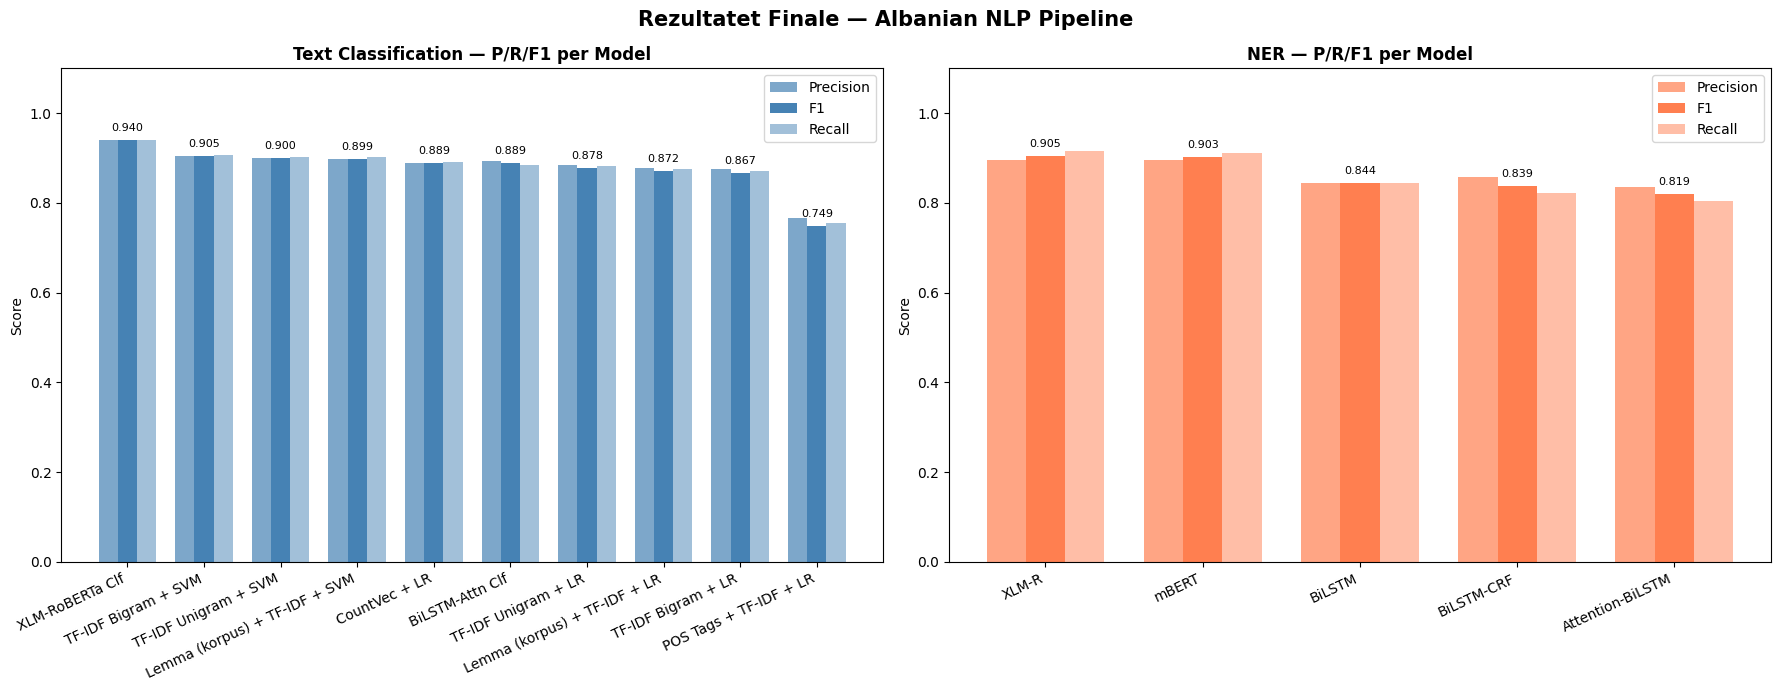

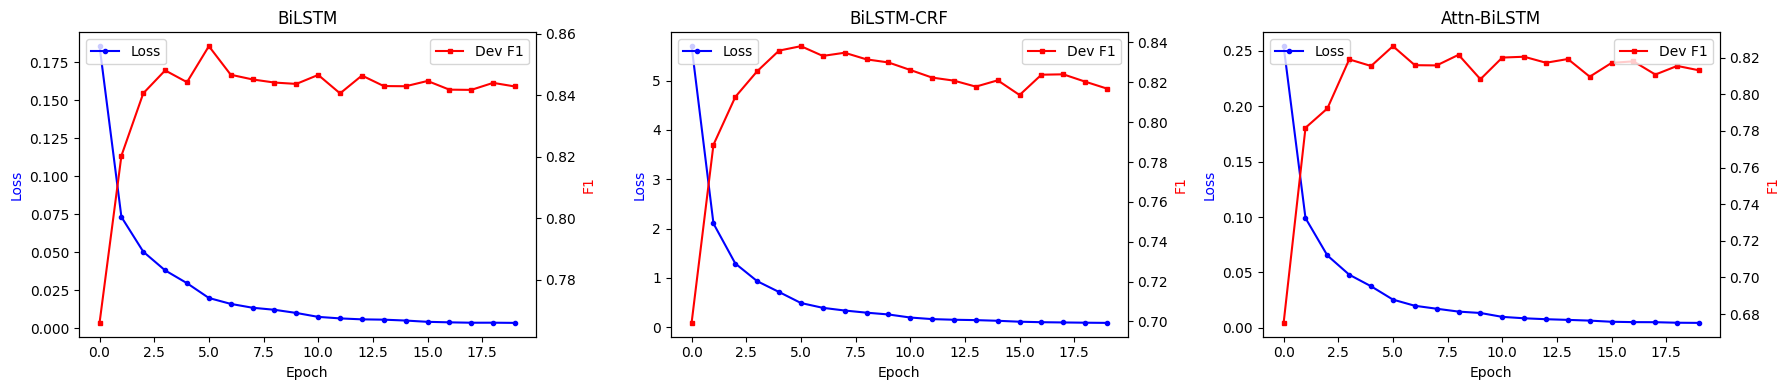


[ NER PER-LABEL REPORT — XLM-R ]


              precision    recall  f1-score   support

      DATE_0       0.90      0.95      0.93      1010
      DATE_1       0.64      0.73      0.68        73
       EVENT       0.77      0.76      0.77        84
         ORG       0.72      0.74      0.73       923
         PER       0.95      0.95      0.95      3079
         PRO       0.52      0.43      0.47        56
       RRUGE       0.41      0.58      0.48        24
       SHESH       0.82      0.94      0.87        33
      VEND_0       0.89      0.94      0.91      1736
      VEND_1       0.94      0.95      0.94      1295

   micro avg       0.89      0.92      0.91      8313
   macro avg       0.76      0.80      0.77      8313
weighted avg       0.90      0.92      0.91      8313



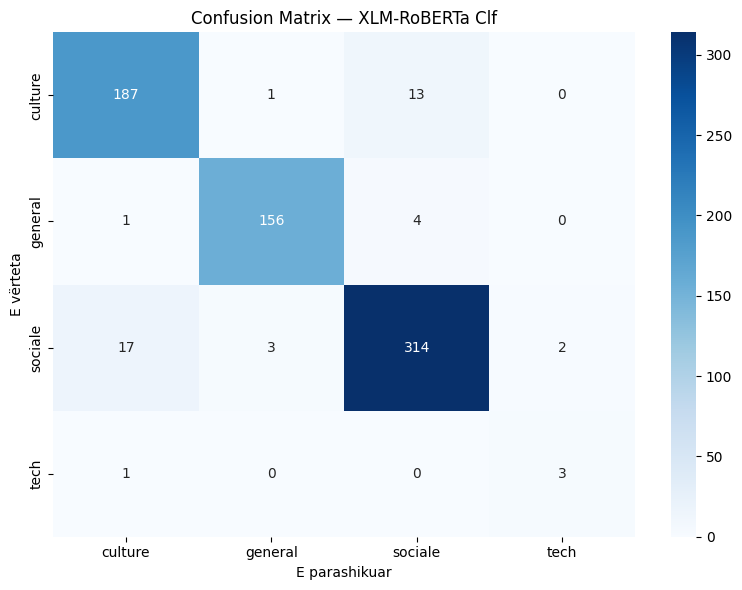

In [26]:
# CELL 17 — TABELË PËRMBLEDHËSE + VIZUALIZIM

# ── TABELA PËRMBLEDHËSE — TEXT CLASSIFICATION ──────────────────────────────────
print('='*65)
print('TABELA PËRMBLEDHËSE — TEXT CLASSIFICATION')
print('='*65)
clf_df = pd.DataFrame([
    {'Model': k, 'Precision': v['precision'], 'Recall': v['recall'], 'F1': v['f1']}
    for k, v in clf_results.items()
]).sort_values('F1', ascending=False).reset_index(drop=True)
print(clf_df.to_string(index=False, float_format='%.4f'))
best_clf_name = clf_df.iloc[0]['Model']
print(f'\n★ Modeli më i mirë: {best_clf_name} (F1={clf_df.iloc[0]["F1"]:.4f})')

# ── TABELA PËRMBLEDHËSE — NER ──────────────────────────────────────────────────
print('\n'+'='*65)
print('TABELA PËRMBLEDHËSE — NER')
print('='*65)
ner_df = pd.DataFrame([
    {'Model': k, 'Precision': v['precision'], 'Recall': v['recall'], 'F1': v['f1']}
    for k, v in ner_results.items()
]).sort_values('F1', ascending=False).reset_index(drop=True)
print(ner_df.to_string(index=False, float_format='%.4f'))
best_ner_name = ner_df.iloc[0]['Model']
print(f'\n★ Modeli NER më i mirë: {best_ner_name} (F1={ner_df.iloc[0]["F1"]:.4f})')

# ── GRAFIKU BAR KRAHASUES ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

def plot_prrf(ax, df, title, color):
    x = np.arange(len(df))
    w = 0.25
    ax.bar(x - w, df['Precision'], w, label='Precision', color=color, alpha=0.7)
    ax.bar(x,     df['F1'],        w, label='F1',        color=color, alpha=1.0)
    ax.bar(x + w, df['Recall'],    w, label='Recall',    color=color, alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels(df['Model'], rotation=25, ha='right')
    ax.set_ylim(0, 1.1); ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score'); ax.legend()
    for i, row in df.iterrows():
        ax.text(i, row['F1'] + 0.02, f"{row['F1']:.3f}", ha='center', fontsize=8)

plot_prrf(axes[0], clf_df, 'Text Classification — P/R/F1 per Model', 'steelblue')
plot_prrf(axes[1], ner_df, 'NER — P/R/F1 per Model', 'coral')

plt.suptitle('Rezultatet Finale — Albanian NLP Pipeline', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'final_results.png', dpi=120, bbox_inches='tight')
plt.show()

# ── TRAINING CURVES ───────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, h) in zip(axes2, [('BiLSTM', h_bilstm), ('BiLSTM-CRF', h_crf), ('Attn-BiLSTM', h_attn)]):
    ax2b = ax.twinx()
    ax.plot(h['loss'], 'b-o', ms=3, label='Loss')
    ax2b.plot(h['dev_f1'], 'r-s', ms=3, label='Dev F1')
    ax.set_title(name); ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='b'); ax2b.set_ylabel('F1', color='r')
    ax.legend(loc='upper left'); ax2b.legend(loc='upper right')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# ── PER-LABEL NER REPORT ──────────────────────────────────────────────────────
print(f'\n[ NER PER-LABEL REPORT — {best_ner_name} ]')
if best_ner_name == 'XLM-R':
    po = tr_xlmr.predict(dte_xlmr); p = np.argmax(po.predictions, axis=2)
    tl, pl = [], []
    for r, l in zip(p, po.label_ids):
        tl.append([id2label[x] for x in l if x != -100])
        pl.append([id2label[x] for x, y in zip(r, l) if y != -100])
    print(seq_report(tl, pl))
elif best_ner_name == 'mBERT':
    po = tr_mbert.predict(dte_mbert); p = np.argmax(po.predictions, axis=2)
    tl, pl = [], []
    for r, l in zip(p, po.label_ids):
        tl.append([id2label[x] for x in l if x != -100])
        pl.append([id2label[x] for x, y in zip(r, l) if y != -100])
    print(seq_report(tl, pl))
elif 'CRF' in best_ner_name: print(seq_report(tt_c, pt_c))
elif 'Attn' in best_ner_name: print(seq_report(tt_a, pt_a))
else: print(seq_report(tt_b, pt_b))

# ── CONFUSION MATRIX CLF ──────────────────────────────────────────────────────
if 'XLM-RoBERTa' in best_clf_name:
    best_preds_clf_final = preds_xlmr_clf
elif 'BiLSTM' in best_clf_name:
    best_preds_clf_final = best_preds_clf
else:
    best_preds_clf_final = best_preds_clf

cm = confusion_matrix(y_te, best_preds_clf_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix — {best_clf_name}')
plt.ylabel('E vërteta'); plt.xlabel('E parashikuar')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'confusion_matrix.png', dpi=120)
plt.show()

## PJESA 9 — Ruajtja e Modeleve

In [27]:
# CELL 18 — RUAJTJA E GJITHË MODELEVE NË DRIVE

json.dump(word2id,  open(SAVE_DIR+'word2id.json',  'w', encoding='utf-8'), ensure_ascii=False)
json.dump(lemma2id, open(SAVE_DIR+'lemma2id.json', 'w', encoding='utf-8'), ensure_ascii=False)
json.dump(label2id, open(SAVE_DIR+'label2id.json', 'w', encoding='utf-8'), ensure_ascii=False)
json.dump(id2label, open(SAVE_DIR+'id2label.json', 'w', encoding='utf-8'), ensure_ascii=False)
json.dump({
    'class_names':    list(class_names),
    'num_classes':    int(NUM_CLASSES),
    'num_ner_labels': int(NUM_NER_LABELS),
    'embed_dim':      EMBED_DIM,
    'hidden_dim':     HIDDEN_DIM,
    'dropout':        DROPOUT,
    'max_len':        MAX_LEN,
    'all_ner_labels': all_ner_labels,
}, open(SAVE_DIR+'config.json', 'w', encoding='utf-8'), ensure_ascii=False)

# Ruaj rezultatet si CSV
clf_df.to_csv(SAVE_DIR + 'clf_results.csv', index=False)
ner_df.to_csv(SAVE_DIR + 'ner_results.csv', index=False)

print('Të gjitha modelet dhe konfiguracionet u ruajtën')
print(f'SAVE_DIR: {SAVE_DIR}')

Të gjitha modelet dhe konfiguracionet u ruajtën
SAVE_DIR: /content/drive/MyDrive/models/


## PJESA 10 — GUI Gradio
> Ekzekuto Cell 19 (ngarkim) nëse rihap notebook-in pas trajnimit.
> Pastaj ekzekuto Cell 20 (GUI).


In [ ]:
# CELL 19 — NGARKO MODELET NGA DRIVE (pa ritrajnuar)
import os, json, pickle, numpy as np, torch, torch.nn as nn, re
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import AutoModelForSequenceClassification
from sklearn.preprocessing import LabelEncoder

SAVE_DIR = '/content/drive/MyDrive/models/'
device   = 'cuda' if torch.cuda.is_available() else 'cpu'

if not os.path.exists(SAVE_DIR + 'config.json'):
    print('Modelet nuk gjenden — ekzekuto trajnimin e plotë fillimisht')
else:
    cfg      = json.load(open(SAVE_DIR + 'config.json'))
    word2id  = json.load(open(SAVE_DIR + 'word2id.json'))
    label2id = json.load(open(SAVE_DIR + 'label2id.json'))
    id2label = {int(k): v for k, v in json.load(open(SAVE_DIR + 'id2label.json')).items()}
    class_names     = cfg['class_names']
    NUM_NER_LABELS  = cfg['num_ner_labels']
    NUM_CLASSES     = cfg['num_classes']
    EMBED_DIM       = cfg['embed_dim']
    HIDDEN_DIM      = cfg['hidden_dim']
    DROPOUT         = cfg['dropout']
    MAX_LEN         = cfg['max_len']
    all_ner_labels  = cfg.get('all_ner_labels', list(label2id.keys()))

    # XLM-R NER
    tok_xlmr = AutoTokenizer.from_pretrained(SAVE_DIR + 'XLM-R_ner/')
    m_xlmr   = AutoModelForTokenClassification.from_pretrained(
                    SAVE_DIR + 'XLM-R_ner/').to(device).eval()

    # XLM-R CLF
    tok_clf     = AutoTokenizer.from_pretrained(SAVE_DIR + 'xlmr_clf/')
    m_xlmr_clf  = AutoModelForSequenceClassification.from_pretrained(
                      SAVE_DIR + 'xlmr_clf/').to(device).eval()

    # BiLSTM-CRF (ngarko klasat)
    from cell14_architectures import BiLSTM_CRF_NER, CRF  # nëse janë në skedar të veçantë
    # ose ridefino klasat këtu nëse janë inline

    print('Modelet u ngarkuan')

In [28]:
# CELL 20 — GRADIO GUI
# Etiketat reale NER (pa normalizim) me ngjyra specifike

import gradio as gr

# Ngjyra për çdo lloj entiteti
NER_COLORS = {
    'PER':    ('#FFD700', '#333'),   # Person — i verdhë
    'ORG':    ('#87CEEB', '#333'),   # Organizatë — blu qielli
    'VEND_0': ('#90EE90', '#000'),   # Qytet — jeshile e lehtë
    'VEND_1': ('#228B22', '#fff'),   # Shtet — jeshile e errët
    'DATE_0': ('#FFB6C1', '#333'),   # Datë — rozë
    'DATE_1': ('#FF69B4', '#fff'),   # Ditë jave — rozë e fortë
    'EVENT':  ('#DDA0DD', '#333'),   # Ngjarje — plum
    'PRO':    ('#FFA500', '#333'),   # Produkt — portokalli
    'RRUGE':  ('#D2691E', '#fff'),   # Rrugë — kafe
    'SHESH':  ('#20B2AA', '#fff'),   # Shesh — teal
}

LEGEND_HTML = (
    '<div style="display:flex;gap:6px;flex-wrap:wrap;margin-top:10px;'
    'padding:8px;background:#f8f8f8;border-radius:6px;font-size:.82em">'
    '<b>Legjenda:</b>'
    + ''.join(
        f'<span style="background:{bg};color:{fg};padding:2px 8px;border-radius:4px">'
        f'{label}</span>'
        for label, (bg, fg) in NER_COLORS.items()
    )
    + '</div>'
)

def build_ner_html(words, labels):
    parts = []
    for w, lbl in zip(words, labels):
        base = lbl.split('-')[-1] if '-' in lbl else 'O'
        col  = NER_COLORS.get(base)
        if col:
            parts.append(
                f'<mark style="background:{col[0]};color:{col[1]};'
                f'border-radius:5px;padding:2px 7px;margin:1px">'
                f'{w}<sup style="font-size:.7em;margin-left:2px">{base}</sup></mark>')
        else:
            parts.append(w)
    return ' '.join(parts)

def predict_ner_xlmr(text):
    words = text.split()
    if not words: return ''
    inp  = tok_xlmr(words, is_split_into_words=True, return_tensors='pt',
                     truncation=True, max_length=MAX_LEN)
    wids = inp.word_ids()
    with torch.no_grad():
        logits = m_xlmr(**{k: v.to(device) for k, v in inp.items()}).logits
    preds = logits.argmax(-1)[0].cpu().numpy()
    wlbls = {}
    for ti, wid in enumerate(wids):
        if wid is not None and wid not in wlbls:
            wlbls[wid] = id2label[preds[ti]]
    return build_ner_html(words, [wlbls.get(i, 'O') for i in range(len(words))])

def predict_category(text):
    with torch.no_grad():
        inp    = tok_clf(text, return_tensors='pt', truncation=True, max_length=256).to(device)
        logits = m_xlmr_clf(**inp).logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    top3  = np.argsort(probs)[::-1][:3]
    best  = class_names[int(top3[0])]
    html  = (f"<div style='padding:12px;background:#f0f8ff;border-radius:8px'>"
             f"<b style='font-size:1.1em'>Kategoria:</b> "
             f"<span style='color:green;font-size:1.4em;font-weight:bold'>{best.upper()}</span>"
             f"<br><br>")
    for idx in top3:
        lbl  = class_names[int(idx)]
        prob = probs[idx]
        bar  = int(prob * 200)
        html += (f"<div style='display:flex;align-items:center;margin:3px 0'>"
                 f"<span style='width:100px'>{lbl}</span>"
                 f"<div style='background:#4CAF50;height:14px;width:{bar}px;"
                 f"border-radius:3px;margin:0 8px'></div>"
                 f"<span>{prob:.1%}</span></div>")
    return html + '</div>'

def full_pipeline(text):
    if not text.strip():
        return '<i style="color:gray">Shkruaj tekst...</i>', '<i style="color:gray">Shkruaj tekst...</i>'
    try:    cat = predict_category(text)
    except Exception as e: cat = f'<span style="color:red">Gabim CLF: {e}</span>'
    try:    ner = predict_ner_xlmr(text) + LEGEND_HTML
    except Exception as e: ner = f'<span style="color:red">Gabim NER: {e}</span>'
    return cat, ner

with gr.Blocks(title='Albanian NLP', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🇦🇱 Albanian NLP Pipeline
    ### Klasifikimi i Teksteve + Identifikimi i Entiteteve (NER) — Etiketat origjinale
    Etiketat NER: **PER** Person | **ORG** Organizatë | **VEND_0** Qytet | **VEND_1** Shtet |
    **DATE_0** Datë | **DATE_1** Ditë jave | **EVENT** Ngjarje | **PRO** Produkt | **RRUGE** Rrugë | **SHESH** Shesh
    """)
    with gr.Row():
        with gr.Column(scale=2):
            txt_in  = gr.Textbox(label='📝 Teksti shqip', lines=5,
                                  placeholder='Shkruaj ose ngjit artikull shqip...')
            with gr.Row():
                btn_run   = gr.Button('🔍 Analizo', variant='primary')
                btn_clear = gr.Button('🗑️ Pastro')
        with gr.Column(scale=3):
            out_cat = gr.HTML(label='📂 Kategoria')
            out_ner = gr.HTML(label='🏷️ Entitetet NER')
    gr.Examples(
        examples=[
            ['Ermonela Jaho vlerësohet si këngëtarja më e mirë femër në Gjermani në vitin 2023.'],
            ['Shqipëria kualifikohet për Euro 2024 pas fitores kundër Polonisë në Tiranë.'],
            ['Kuvendi i Shqipërisë miratoi buxhetin e vitit 2024 me 80 vota pro të hënën.'],
            ['Festivali Ndërkombëtar i Filmit u mbajt në sheshin Skënderbej më 15 mars 2023.'],
        ],
        inputs=[txt_in]
    )
    btn_run.click(fn=full_pipeline, inputs=[txt_in], outputs=[out_cat, out_ner])
    btn_clear.click(fn=lambda: ('', '', ''), outputs=[txt_in, out_cat, out_ner])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://38ff83c9a3d7ac0192.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
